## Chapter 2 – Group Exercise 1 - Data Preprocessing on a Real Dataset


Group Members: Nihal Sarvagnya Pujari, Namrata Bhoyar, Anuj Kamble, Gourav sathegala somanna, Pramodkumar Shivanna

Fraud Detection Transactions Dataset - This dataset contains transaction-level information such as amount, type, device, location, user behavior signals, and a fraud label (Fraud_Label). The goal is to predict whether a transaction is fraudulent.Transaction data with amounts, risk scores, device types, and fraud labels for ML preprocessing practice.

We're applying missing value imputation, scaling, noise smoothing, outlier removal, and feature selection to prepare this data for fraud prediction modeling.

In [3]:
#Importing all the necessary liabraries
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from scipy import stats
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Fraud Detection Transactions Dataset.csv")

print(df.shape)
df.head()

(50000, 21)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


### Handling Missing Values

In [5]:
df_mv = df.copy()

df_mv.isna().sum()
num_cols = df_mv.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df_mv.select_dtypes(include=["object"]).columns.tolist()

np.random.seed(42)
for col in num_cols[:3]:
    idx = np.random.choice(df_mv.index, size=200, replace=False)
    df_mv.loc[idx, col] = np.nan

for col in cat_cols[:2]:
    idx = np.random.choice(df_mv.index, size=200, replace=False)
    df_mv.loc[idx, col] = np.nan

df_mv.isna().sum()
num_imputer = SimpleImputer(strategy="median")
df_mv[num_cols] = num_imputer.fit_transform(df_mv[num_cols])
cat_imputer = SimpleImputer(strategy="most_frequent")
df_mv[cat_cols] = cat_imputer.fit_transform(df_mv[cat_cols])
df_mv.isna().sum()

Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64

###  Scaling Numerical Features

In [6]:
scaler_z = StandardScaler()
df_z = pd.DataFrame(
    scaler_z.fit_transform(df_mv[num_cols]),
    columns=[c + "_z" for c in num_cols]
)
scaler_mm = MinMaxScaler()
df_mm = pd.DataFrame(
    scaler_mm.fit_transform(df_mv[num_cols]),
    columns=[c + "_mm" for c in num_cols]
)
df_mv[["Transaction_Amount"]].head()
df_z[["Transaction_Amount_z"]].head()
df_mm[["Transaction_Amount_mm"]].head()


,Transaction_Amount_mm
0,0.033889
1,0.001014
2,0.024665
3,0.216601
4,0.026641


### Handling Noise

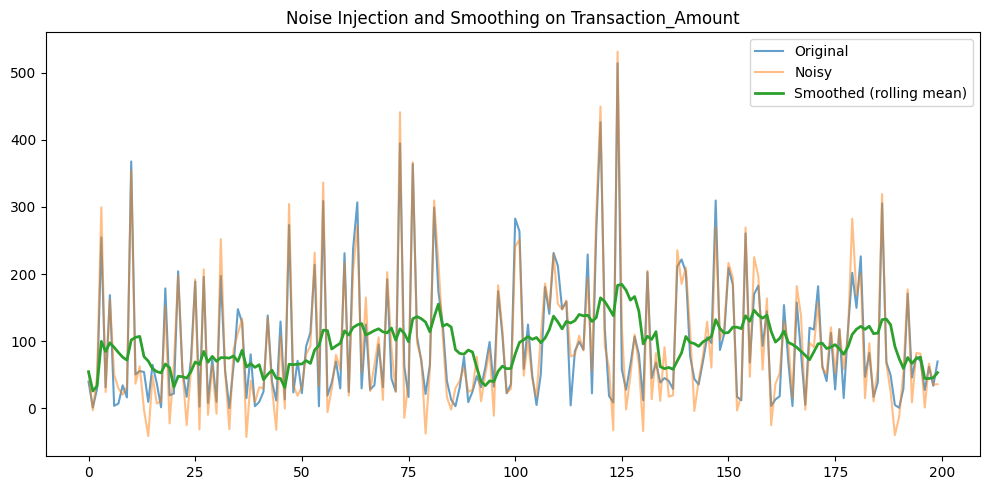

In [7]:
# Compare plot 
feature = "Transaction_Amount"
orig = df_mv[feature].reset_index(drop=True)
np.random.seed(42)
noise = np.random.normal(loc=0, scale=orig.std() * 0.3, size=len(orig))
noisy = orig + noise
smoothed = noisy.rolling(window=10, min_periods=1).mean()
noise_sample = pd.DataFrame({
    feature + "_orig": orig.head(20),
    feature + "_noisy": noisy.head(20),
    feature + "_smooth": smoothed.head(20)
})
noise_sample.to_csv("sample_noise_smoothing.csv", index=False)
plt.figure(figsize=(10,5))
plt.plot(orig[:200].values, label="Original", alpha=0.7)
plt.plot(noisy[:200].values, label="Noisy", alpha=0.5)
plt.plot(smoothed[:200].values, label="Smoothed (rolling mean)", linewidth=2)
plt.legend()
plt.title("Noise Injection and Smoothing on Transaction_Amount")
plt.tight_layout()
plt.show()

### Handling Outliers

We detect outliers using the Z-score method (|z| > 3).


In [8]:
feature = "Transaction_Amount"
z_scores = np.abs(stats.zscore(df_mv[feature]))
threshold = 3 
outliers_mask = z_scores > threshold
print("Number of outliers:", outliers_mask.sum())
df_no_outliers = df_mv[~outliers_mask].copy()
print("Shape after removing outliers:", df_no_outliers.shape)

Number of outliers: 920
Shape after removing outliers: (49080, 21)


### Feature Selection

In [9]:
num_cols = df_no_outliers.select_dtypes(include=["int64", "float64"]).columns.tolist()

label_col = "Fraud_Label"
y = df_no_outliers[label_col].values
if df_no_outliers[label_col].dtype == "object":
    le = LabelEncoder()
    y = le.fit_transform(df_no_outliers[label_col])

X_num = df_no_outliers[num_cols].copy()
mi_scores = mutual_info_classif(X_num, y, random_state=42)

mi_df = pd.DataFrame({
    "feature": num_cols,
    "mi_score": mi_scores
}).sort_values("mi_score", ascending=False)

mi_df.to_csv("feature_selection_mi.csv", index=False)
mi_df.head(10)

,feature,mi_score
11,Fraud_Label,0.630956
6,Failed_Transaction_Count_7d,0.286716
9,Risk_Score,0.200823
10,Is_Weekend,0.004784
4,Daily_Transaction_Count,0.003148
7,Card_Age,0.001898
8,Transaction_Distance,0.001435
3,Previous_Fraudulent_Activity,0.000874
0,Transaction_Amount,0.000000
1,Account_Balance,0.000000
